# ConnectaTel Customer Analysis

## Objective

As a data analyst, the goal of this project is to evaluate customer behavior for a telecommunications company in Latin America, ConnectaTel.

Using data up to the year 2024, this analysis aims to understand usage patterns, identify atypical behavior, and segment customers based on their consumption.

---

## Datasets

This project uses three datasets:

- **plans.csv** → information about current plans (price, included minutes, data limits, extra costs)
- **users_latam.csv** → customer information (age, city, registration date, plan, churn)
- **usage.csv** → detailed service usage (calls and messages)

---

## Methodology

The analysis will follow these steps:

1. Data loading and initial exploration  
2. Data cleaning and validation  
3. Exploratory Data Analysis (EDA)  
4. Customer segmentation  
5. Detection of outliers and unusual behavior  

---

## Business Value

This analysis aims to:

- Identify customer consumption patterns  
- Detect potential churn risks  
- Support retention strategies  
- Suggest improvements to current service plans  

---

## Step 1: Data Loading and Exploration

Before cleaning or merging the data, it is important to understand its structure.

At this stage, we will:
- Load the datasets into memory  
- Inspect their structure and data types  
- Perform an initial validation of the data  

### 1.1 Load Data and Initial Inspection

**Objective:**  
Load all datasets and perform a preliminary review.

**Tasks:**

- Import required libraries (pandas, seaborn, matplotlib)  
- Load the CSV files:
  - `/datasets/plans.csv`
  - `/datasets/users_latam.csv`
  - `/datasets/usage.csv`
- Store them in:
  - `plans`
  - `users`
  - `usage`
- Display the first rows using `.head()`

## Data Loading and Initial Exploration

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [7]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [8]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [9]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Dataset Structure Exploration

#### Objective

Understand the structure of each dataset by reviewing the number of rows and columns, identifying data types, and detecting potential issues such as missing values or inconsistencies before proceeding with the analysis.

---

### Approach

In this step, we will:

- Use `.shape` to examine the dimensions of each dataset  
- Use `.info()` to review column names, data types, and non-null values  

This will help ensure that the data is correctly loaded and ready for further cleaning and analysis.

In [10]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


---

## 2. Data Quality Assessment

### 2.1 Missing Values Analysis

#### Objective

Identify the presence and magnitude of missing values in each dataset in order to evaluate their potential impact on the analysis and determine appropriate handling strategies (imputation, removal, or retention).

---

#### Approach

In this step, we will:

- Count the number of missing values per column  
- Calculate the proportion of missing values per column  

This helps prioritize which columns require further investigation or cleaning.

In [12]:
print("Users - Missing Values (Count):")
print(users.isna().sum())

print("\nUsers - Missing Values (Proportion):")
print(users.isna().mean())

Users - Missing Values (Count):
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Users - Missing Values (Proportion):
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
print("\nUsage - Missing Values (Count):")
print(usage.isna().sum())

print("\nUsage - Missing Values (Proportion):")
print(usage.isna().mean())


Usage - Missing Values (Count):
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Usage - Missing Values (Proportion):
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


### Diagnosis

#### Users dataset

- **city (~11.7% missing):** Moderate level of missing values. This column should be investigated further. Possible actions include imputing with the most frequent city or labeling as "unknown".
- **churn_date (~88.3% missing):** Very high proportion of missing values. However, this is likely expected, since only churned users would have a churn date. This column should be retained and interpreted carefully rather than removed.

---

#### Usage dataset

- **date (~0.1% missing):** Very low proportion of missing values. This can be safely handled by removing or imputing.
- **duration (~55.2% missing) and length (~44.7% missing):** High proportion of missing values. This likely depends on the type of record (e.g., calls vs messages). These columns should not be dropped immediately; instead, they should be analyzed in relation to the "type" column to determine if the missing values are expected.

---

#### Comments

- Some missing values are structural (expected based on the data context), not errors.
- Moderate missing values require investigation before deciding on imputation.
- High missing values should not always be removed without understanding their meaning.

## 2.2 Detection of Invalid Values and Sentinels

### Objective

Identify invalid values or sentinels (values that should not exist in the dataset) in both numerical and categorical columns.

---

### Approach

In this step, we will:

- Explore numerical columns using statistical summaries  
- Inspect categorical columns using unique values  
- Identify potential anomalies or unrealistic values  

In [21]:
# explore numerical columns from users
users['user_id'].describe()

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

In [16]:
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- The column `user_id` contains values ranging from 10000 to 13999, which appear sequential and consistent. This confirms that it functions as an identifier. No invalid values are detected.

- The column `age` shows an invalid minimum value of -999, which is not a realistic age. This indicates the presence of a sentinel value used to represent missing or incorrect data. This value should be replaced with NaN and handled appropriately during data cleaning.

In [22]:
# explore numerical columns from usage
usage['id'].describe()

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

In [18]:
usage['user_id'].describe()

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

- The column `id` contains values ranging from 1 to 40000, which appear sequential and consistent. This indicates that it functions as a unique identifier for each record. No invalid values are detected.

- The column `user_id` contains values between 10000 and 13999, which align with the expected range of user identifiers. The values appear consistent and valid, with no anomalies detected.

In [20]:
# explore categorical columns from users
columnas_user = ['city', 'plan']

users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- The column `city` contains 7 unique categories, with Bogotá being the most frequent. The total count (3531) is lower than the total number of records, indicating the presence of missing values. No invalid or unexpected categories are observed.

- The column `plan` contains 2 categories, with "Basico" being the most frequent. The values appear consistent and complete, with no missing or invalid entries.

In [24]:
# explore categorical column from usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- The column `type` contains 2 categories, with "text" being the most frequent. The values are consistent and no invalid categories are detected.

### Diagnosis

No invalid categorical values or sentinels were detected in the datasets.

The column `city` contains missing values, which should be handled through imputation (e.g., "unknown") or further analysis.

The columns `plan` and `type` are clean, with consistent and expected categories.

Overall, categorical variables do not present quality issues, but missing values in `city` should be addressed.

## 2.3 Date Review and Standardization

### Objective

Ensure that date columns are properly formatted and identify any out-of-range values that may indicate data entry errors.

---

### Approach

In this step, we will:

- Convert date columns to a proper datetime format using a robust method  
- Extract and analyze the distribution of years  
- Identify any unrealistic or out-of-range dates (e.g., future years beyond 2024 or invalid values)  

This validation is essential to ensure temporal consistency before performing further analysis.

In [26]:
# Convert the `reg_date` column in users to datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [27]:
# Convert the `date` column in usage to datetime
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [28]:
# Review the years present in `reg_date` from users
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

In `reg_date`, most values fall within the expected range (2022–2024). However, there are 40 records with the year 2026, which is beyond the expected data range.

Since the dataset only includes data up to 2024, these values are considered invalid and likely due to data entry errors.

In [30]:
# Review the years present in `date` from usage
usage['date'].dt.year.value_counts().sort_index()

date
2024.0    39950
Name: count, dtype: int64

In `date`, all values correspond to the year 2024. No out-of-range or invalid dates are detected, and the data appears consistent with the expected time period.

### Diagnosis

Out-of-range dates were identified in the `reg_date` column, specifically values from the year 2026. Since the dataset only includes data up to 2024, these records are considered invalid and likely due to data entry errors.

In contrast, the `date` column contains only valid values from the year 2024, with no inconsistencies detected.

Recommended actions:
- For `reg_date`: replace invalid dates (e.g., 2026) with NaT or remove the affected records.
- For `date`: no action is required, as the data is consistent and within the expected range.

---

## 3. Data Cleaning

### 3.1 Correcting Sentinels and Invalid Dates

#### Objective

Apply cleaning rules to correct sentinel values and handle invalid dates in the dataset.

---

#### Approach

In this step, we will:

- Replace sentinel values in numerical columns using appropriate statistics (median)  
- Convert invalid categorical placeholders into missing values  
- Identify and mark out-of-range dates as missing  

This ensures the dataset is consistent and ready for analysis.

In [31]:
# calculate median excluding sentinel values
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# replace sentinel with median
users['age'] = users['age'].replace(-999, age_mediana)

# verify
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [32]:
# replace "?" with NA
users['city'] = users['city'].replace("?", pd.NA)

# verify
users['city'].isna().sum()

np.int64(565)

In [33]:
# mark dates beyond 2024 as NA
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# verify
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

### 3.2 Handling Missing Values Based on Context

#### Objective

Determine how to handle missing values in the dataset by analyzing their proportion and whether they depend on other variables.

---

#### Approach

In this step, we will:

- Check if missing values in `duration` and `length` depend on the column `type`  
- Identify whether the missingness is Missing At Random (MAR)  
- Decide whether to keep or modify the missing values based on their context  

In [34]:
# Check missing values in duration by type
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [35]:
# Check missing values in length by type
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

### Diagnosis

The missing values in `duration` and `length` clearly depend on the variable `type`.

For `duration`, nearly 100% of missing values occur in records of type "text", while there are no missing values for "call". This indicates that messages do not have a duration.

For `length`, nearly all missing values occur in records of type "call", while text messages have complete values. This suggests that calls do not have a text length.

This pattern confirms that the missing values are structural and depend entirely on the type of record. Therefore, they are not errors but expected behavior.

Recommended action: keep the missing values as they are, since they correctly represent the nature of the data.

---

## 4. Summary Statistics by User

### 4.1 Aggregation of Usage Behavior

#### Objective

Summarize key usage variables at the user level by creating metrics that reflect each user’s historical behavior.

---

#### Approach

In this step, we will:

- Create auxiliary variables to identify calls and messages  
- Aggregate usage data by user_id  
- Compute total messages, total calls, and total call duration  
- Rename columns for clarity  
- Merge the aggregated data with the users dataset  

In [36]:
# Auxiliary columns
usage["is_text"] = (usage["type"] == "text").astype(int)  # total number of messages
usage["is_call"] = (usage["type"] == "call").astype(int)  # total number of calls


# Group information by user
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# view result
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Rename columns
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# view result
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Merge aggregated table with users dataset
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 User-Level Statistical Summary (2024)

#### Objective

Analyze numerical and categorical variables to identify ranges, extreme values, and data distribution before continuing the analysis.

---

#### Approach

- Generate summary statistics for key numerical variables  
- Analyze the percentage distribution of the categorical variable `plan`  

In [39]:
# Statistical summary of numerical columns
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [40]:
# Percentage distribution of plan type
user_profile["plan"].value_counts(normalize=True)

plan
Basico     0.64875
Premium    0.35125
Name: proportion, dtype: float64

---

## 5. Visualization of Distributions and Outliers

### 5.1 Distribution Visualization

#### Objective

Visually understand how key variables behave for both usage and users, identify differences between plans, and analyze the shape of the distributions.

---

#### Approach

- Plot histograms for key variables  
- Compare distributions using the `plan` variable  
- Identify patterns, skewness, and potential outliers  

After each plot, we will describe:

- Differences between plans  
- Distribution shape (symmetric, right-skewed, or left-skewed)  
- Key behavioral insights  

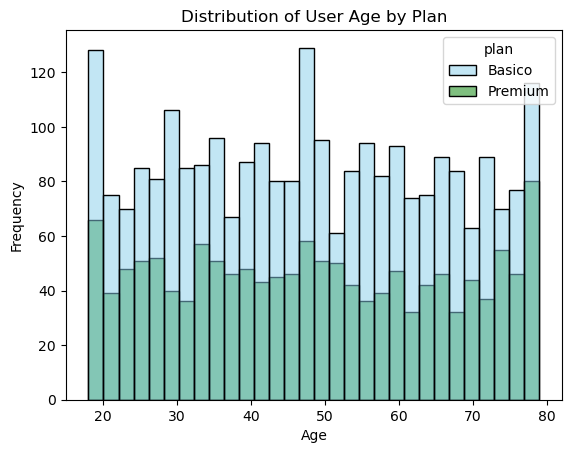

In [41]:
# Histogram to visualize age
sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue", "green"], bins=30)

plt.title("Distribution of User Age by Plan")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Insights:
- The age distribution appears relatively uniform, with no strong concentration in a specific age group.
- There is no significant difference between Basic and Premium users in terms of age distribution.
- The distribution is approximately symmetric, with no clear skewness.
- This suggests that plan choice is not strongly influenced by user age.

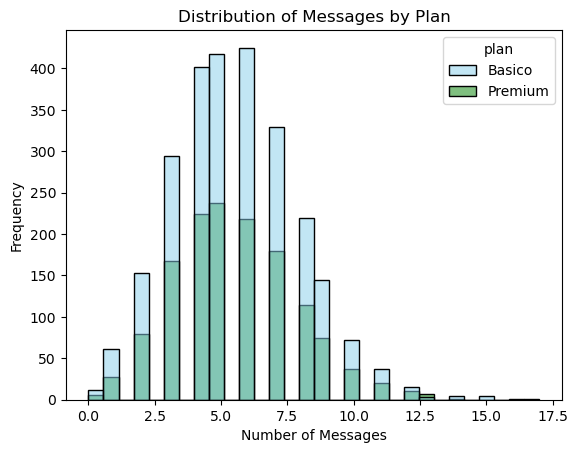

In [42]:
# Histogram to visualize cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue", "green"], bins=30)

plt.title("Distribution of Messages by Plan")
plt.xlabel("Number of Messages")
plt.ylabel("Frequency")

plt.show()

### Insights:
- The distribution of messages is right-skewed, with most users sending a low to moderate number of messages.
- Both Basic and Premium users show similar patterns, with no strong separation between plans.
- A small number of users send a higher number of messages, indicating potential heavy users.
- Overall, there is no clear behavioral difference between plans in terms of messaging activity.

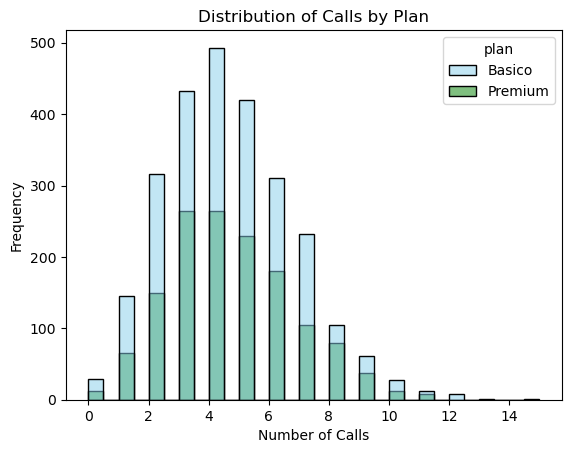

In [43]:
# Histogram to visualize cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue", "green"], bins=30)

plt.title("Distribution of Calls by Plan")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")

plt.show()

### Insights:
- The distribution of calls is right-skewed, with most users making a moderate number of calls.
- Basic users appear slightly more concentrated in lower call ranges, while Premium users show a slightly wider spread.
- There are some users with a high number of calls, indicating potential outliers or heavy users.
- The difference between plans is present but not strongly pronounced.

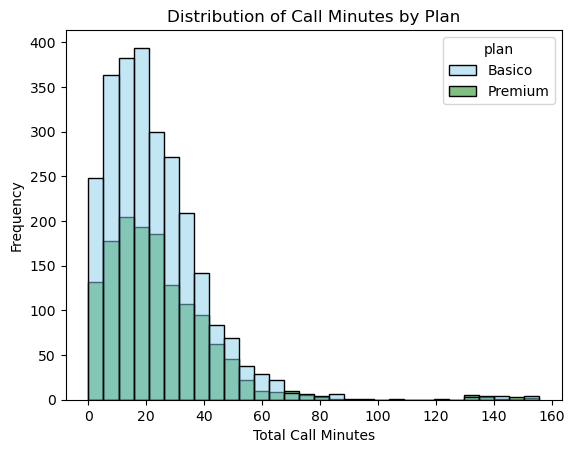

In [44]:
# Histogram to visualize cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue", "green"], bins=30)

plt.title("Distribution of Call Minutes by Plan")
plt.xlabel("Total Call Minutes")
plt.ylabel("Frequency")

plt.show()

### Insights:
- The distribution of call minutes is strongly right-skewed, with most users having low usage and a few with very high values.
- Premium users tend to have slightly higher call minutes compared to Basic users.
- There are clear outliers with very high call durations, indicating heavy usage behavior.
- This suggests that Premium users may use more voice services, but the difference is not extreme.

---

### 5.2 Outlier Identification

#### Objective

Detect extreme values in key usage and user variables that could affect the analysis, and determine whether they require cleaning or further review.

---

#### Approach

- Use boxplots to visually identify outliers in key variables  
- Evaluate whether outliers are present and if they are meaningful  
- If necessary, calculate limits using the IQR method  
- Decide whether to keep or treat outliers based on their context  

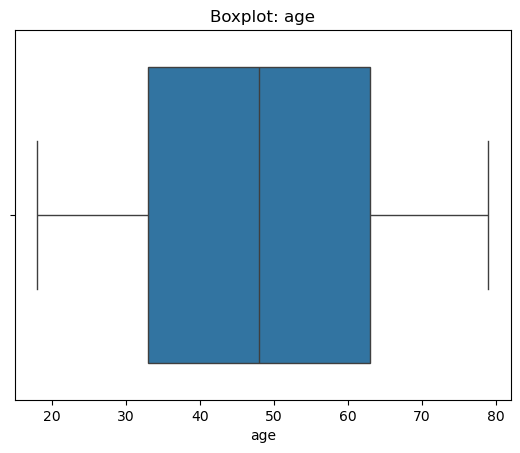

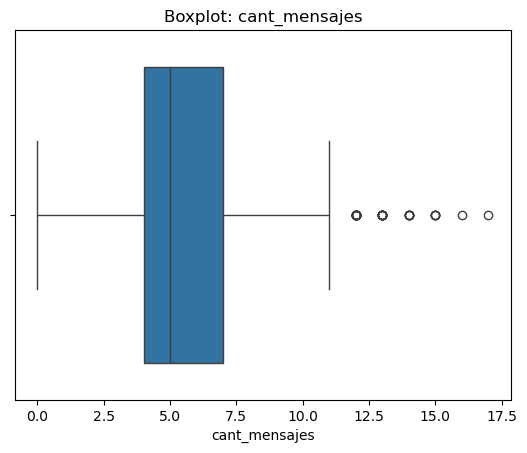

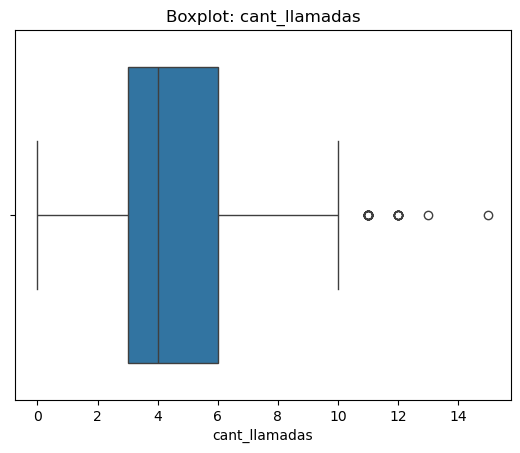

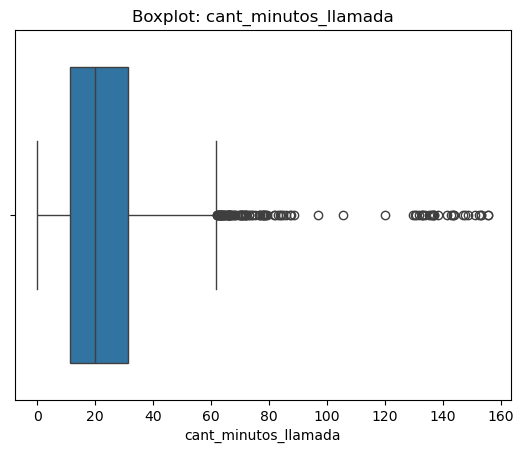

In [46]:
# Visualizing using BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

### Insights: 
- Age: No significant outliers are observed. The values are well distributed within a realistic range, indicating clean and consistent data.

- cant_mensajes: Outliers are present on the right side. These represent users who send a higher number of messages than typical users, indicating heavy usage behavior.

- cant_llamadas: Outliers are observed on the right side. A small number of users make significantly more calls than average, suggesting high usage segments.

- cant_minutos_llamada: A large number of outliers are present on the right side. These correspond to users with very high call durations, indicating heavy users. These values are likely valid and reflect real behavior rather than errors.

In [47]:
# Calculate limits using IQR method
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Lower limit: {lower_limit}")
    print(f"Upper limit: {upper_limit}")
    print()

cant_mensajes
Lower limit: -0.5
Upper limit: 11.5

cant_llamadas
Lower limit: -1.5
Upper limit: 10.5

cant_minutos_llamada
Lower limit: -19.322500000000005
Upper limit: 61.8575



In [48]:
# Review upper limits vs actual max values
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


### Insights:
- cant_mensajes: Outliers exceed the upper limit (11.5) with a maximum value of 17. However, the difference is not extreme, and these values likely represent users with higher messaging activity. The outliers should be kept, as they reflect real user behavior.

- cant_llamadas: Outliers exceed the upper limit (10.5) with a maximum value of 15. Similar to messages, these values are not excessively far from the upper bound and likely represent high-usage users. The outliers should be maintained.

- cant_minutos_llamada: Outliers significantly exceed the upper limit (61.86) with a maximum value of 155.69. Although the gap is larger compared to other variables, these values are consistent with heavy users and do not appear to be data errors. Therefore, the outliers should be kept.

---

## 6. Customer Segmentation

### 6.1 Usage-Based Segmentation

#### Objective

Classify each user into a usage group (Low, Medium, High) based on their number of calls and messages.

---

#### Approach

- Create a new column `grupo_uso`  
- Use logical conditions based on calls and messages  
- Assign users into three categories: Low usage, Medium usage, and High usage  

In [50]:
# Create grupo_uso column
user_profile["grupo_uso"] = "Alto uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "grupo_uso"
] = "Bajo uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
    "grupo_uso"
] = "Uso medio"

# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Uso medio


---

### 6.2 Age-Based Segmentation

#### Objective

Classify users into age groups based on their age.

---

#### Approach

- Create a new column `grupo_edad`  
- Use logical conditions to assign users into age categories  

In [51]:
# Create grupo_edad column
user_profile["grupo_edad"] = "Adulto Mayor"

user_profile.loc[
    user_profile["age"] < 30,
    "grupo_edad"
] = "Joven"

user_profile.loc[
    user_profile["age"] < 60,
    "grupo_edad"
] = "Adulto"

# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Uso medio,Adulto Mayor


---

### 6.3 Visualization of Customer Segmentation

#### Objective

Visualize the distribution of users across the defined segments: usage group and age group.

---

#### Approach

- Create count plots for categorical variables  
- Analyze how users are distributed across segments  

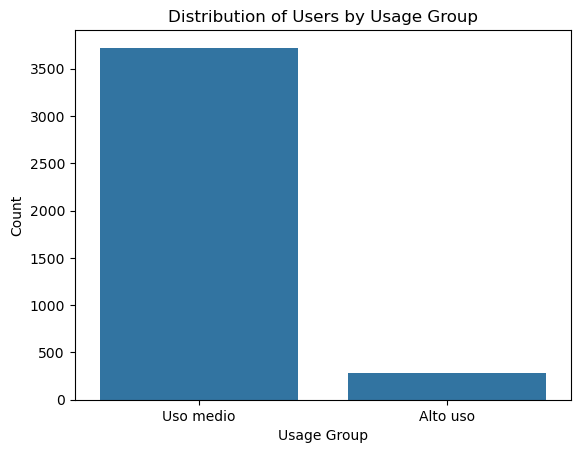

In [54]:
# Visualization of usage segments
sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribution of Users by Usage Group")
plt.xlabel("Usage Group")
plt.ylabel("Count")

plt.show()

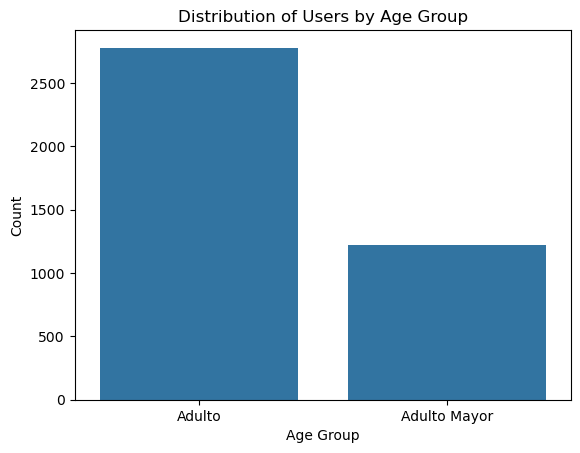

In [55]:
# Visualization of age segments
sns.countplot(data=user_profile, x="grupo_edad")

plt.title("Distribution of Users by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

---

## 7. Business Analysis

### Data Issues Identified

Several data quality issues were detected during the analysis:

- The `age` column contained sentinel values (-999), representing invalid entries that were replaced using the median.
- The `city` column contained missing values (~11.7%), which were identified as incomplete categorical data.
- The `reg_date` column included out-of-range values (year 2026), which exceeded the expected data range (up to 2024) and were treated as invalid.
- Missing values in `duration` and `length` were identified as structural (dependent on `type`) and therefore retained.

---

### Segments by Age

Users were segmented into three age groups:

- Young (<30)
- Adult (30–59)
- Senior (60+)

The age distribution is relatively balanced, with no strong concentration in a specific group. Additionally, no clear relationship was observed between age and plan selection, suggesting that age is not a primary driver of customer behavior.

---

### Segments by Usage Level

Users were classified into:

- Low usage
- Medium usage
- High usage

Most users fall within low to medium usage levels, while a smaller group represents high-usage customers. These high-usage users are characterized by higher numbers of calls, messages, and call minutes.

This suggests that while the majority of users have moderate activity, there is a valuable segment of heavy users that could be strategically targeted.

---

### Extreme Usage Patterns (Outliers)

Outliers were identified in:

- Messages
- Calls
- Call minutes

These outliers are primarily located on the upper end and represent heavy users rather than data errors. In particular, call minutes show significant variability, with some users reaching very high usage levels.

This implies the existence of a segment with intensive service consumption, which may have higher revenue potential.

---

### Recommendations

- Develop targeted plans for high-usage users, such as premium plans with better pricing for large volumes of calls or minutes.
- Consider creating mid-tier plans to better capture users in the medium usage segment.
- Maintain flexibility in plan design, as user behavior varies significantly and is not strongly driven by age.
- Use usage-based segmentation to personalize offers and improve customer retention.